# Time series analysis (Part 2)

## Customizing our baseline model

In the first part, we created a naive seasonal forecast model. The very simple assumption that the data in the current period may be estimated by the data from the previous period led to an estimation that was off by almost 23%. The aim is now, can we make it better without using more complicated approaches like ARIMA/SARIMA and understand better the timeseries analysis benefits.

## How the trend is calculated?

In the previous code we used the command `seasonal_decompose(df['min_temperature'], model='additive', period=365)`. The period of the 365 days comes from the structure of our data and matches the yearly cycle we can observe. The algorithm calculates a 365 days centered moving average which uses 182 points before and after the actual value to determine the average (therefore the gaps in the trend and residues). 
Then, the algoritm calculates the seasonality by grouping all January 1st days and average those, then January 2nd, and so on (that's why the seasonal data does not have the gaps). 

From the additive model we know that we have:

$Y = T + S + R$ 

and we can now express the detrended data by: 

$Y - T = S + R$

and also the residuals by: 

$Y - T - S = R$.

## A strategy for a new baseline model

The first naive baseline model used only the data of only one season for the estimation. Having understood how the decompositions works we can create a model that depends on the seasonality and the trend of a larger set of years. We can simply add the extracted trend and seasonality which essentially assumes that the noise (residuals) is zero.

Last trend value used for forecast: 1.29°C


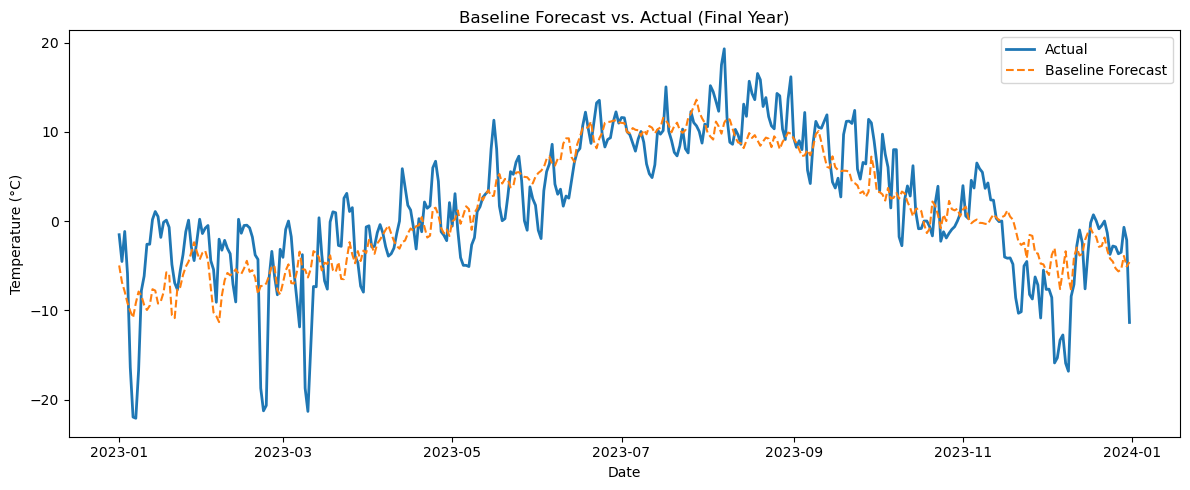

SMAPE for Baseline Model on Final Year: 20.93%


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# import sklearn.metrics for MAPE calculation 
# from sklearn.metrics import mean_absolute_percentage_error  

# Load the data
df = pd.read_csv('data/SMEAR_2m_daily_min_temperature.csv', parse_dates=['date'])
# print(df.head()) # See hat we have
# print(df.dtypes) # Check data types

# Set the 'date' as the index
df.set_index('date', inplace=True)

# Set a regular daily frequency and fill missing values using forward fill
df = df.asfreq('D')
df['min_temperature'] = df['min_temperature'].ffill()

# Split into training (all years except final) and testing (final year)
train = df[df.index.year < df.index.year.max()].copy()
test = df[df.index.year == df.index.year.max()].copy()

# Decompose the training data
decomposition = seasonal_decompose(train['min_temperature'], model='additive', period=365)

# Extract components
trend = decomposition.trend
seasonal = decomposition.seasonal

# Use last full year of seasonal values from training to repeat for test
seasonal_values = seasonal[-365:].values
seasonal_test = pd.Series(seasonal_values[:len(test)], index=test.index)

# Extend last valid trend value as constant across the test period
trend_last = trend.dropna().iloc[-1]
trend_test = pd.Series(trend_last, index=test.index)
print(f"Last trend value used for forecast: {trend_last:.2f}°C")

# Create baseline forecast
baseline_forecast = trend_test + seasonal_test
# print(baseline_forecast)

# Get actual values for the test period
actual = test['min_temperature']

# Plot actual vs. forecast
plt.figure(figsize=(12, 5))
plt.plot(actual.index, actual, label='Actual', linewidth=2)
plt.plot(actual.index, baseline_forecast, label='Baseline Forecast', linestyle='--')
plt.title('Baseline Forecast vs. Actual (Final Year)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

# SMAPE Calculation
smape_bl = np.mean(np.abs(test['min_temperature'] - baseline_forecast) / (np.abs(test['min_temperature']) + np.abs(baseline_forecast))/2) * 100
print(f"SMAPE for Baseline Model on Final Year: {smape_bl:.2f}%")

## Result for the new baseline model

The SMAPE dropped by about 2% to now 20.93% which tells that this new baseline model improved our estimations, not dramatically, and we have a lower deviation from the original values in our testdata of the year 2023.

The model we have been using is actually called the **standard decomposition-based baseline** model!

## Let's build our own custom baseline model

We can use a more integrated criteria than just the naive approach with same temperature as last season (part 1) and the standard decomposition based baseline (part 2, above) where we rely on **only one season** for the prediction.

We can think of averaging the daily temperature fo all years before our "test year" and by that create a one year averaged dataset that we can use to make the estimation. This approach, however, assumes that all the years have a similar impact on the prediction and we may miss out longer term fluctuations like we saw the some subsequent years were overall warmer. 

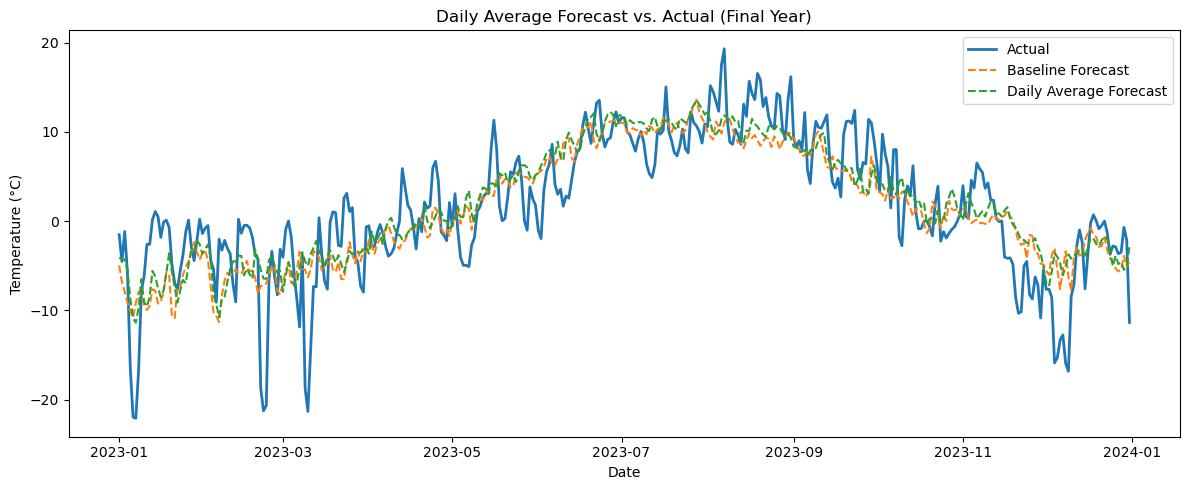

SMAPE for Daily Average Model on Final Year: 20.90%


In [14]:
# Create a new column 'day_of_year' representing which day (1 to 365) each date falls on
train.loc[:, "day_of_year"] = train.index.dayofyear
test.loc[:, "day_of_year"] = test.index.dayofyear

# Group the training data by 'day_of_year' and calculate the mean temperature for each day (averaged across all years)
daily_avg = train.groupby("day_of_year")["min_temperature"].mean()

# Use the learned seasonal pattern to forecast test data by mapping test days to the corresponding daily average
day_avg_forecast = test["day_of_year"].map(daily_avg)

# Plot actual vs. forecast
plt.figure(figsize=(12, 5))
plt.plot(actual.index, actual, label='Actual', linewidth=2)
plt.plot(actual.index, baseline_forecast, label='Baseline Forecast', linestyle='--')
plt.plot(actual.index, day_avg_forecast, label='Daily Average Forecast', linestyle='--')
plt.title('Daily Average Forecast vs. Actual (Final Year)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

# SMAPE Calculation
smape_dav = np.mean(np.abs(test['min_temperature'] - day_avg_forecast) / (np.abs(test['min_temperature']) + np.abs(day_avg_forecast))/2) * 100
print(f"SMAPE for Daily Average Model on Final Year: {smape_dav:.2f}%")

We got a little bit smaller deviation of our forecast to the original values. The drop to 20.90% is just 0.03% and actually tells that our baseline model and the custom daily temperature averaged approach are almost similar. 

## Can we improve more?

So far, we skip some details in our data, namely we treat every year as it had similar number of days. In leap years, we miss out the 29<sup>th</sup> of February in 2026 and 2020. Would that matter? Actually yes, in timeseries analysis every moment may have some impact and the better we can capture data features the better we get our prediction. 

## Let's develop a new custom baseline model with calendar day averaging

We will build a custom baseline using averages per calendar-day by looking at how the temperature usually behaves on each month and day across the years to capture the seasonal rhythm over the year.  Using the actual calendar day this also includes the additional day in leap years.

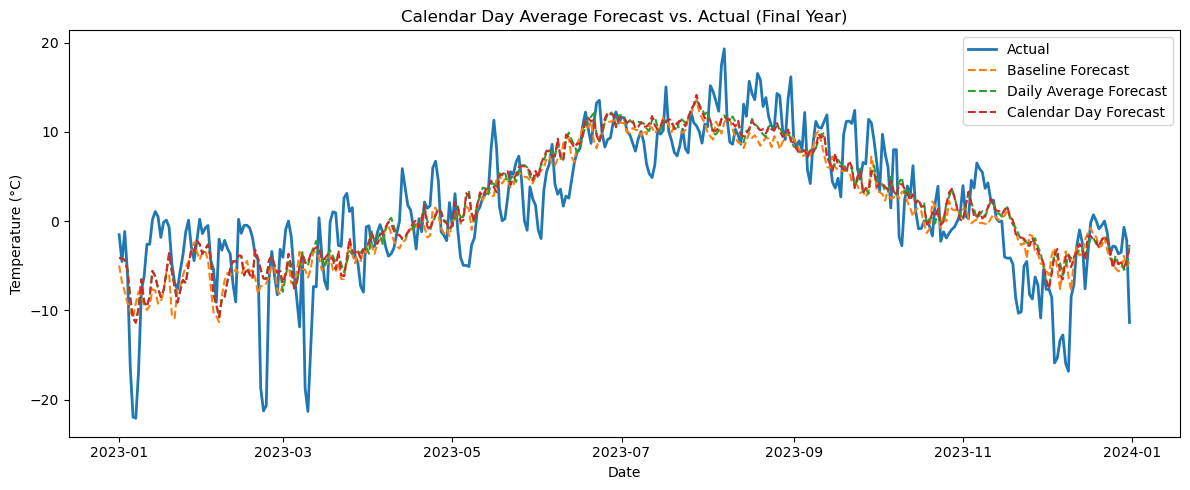

SMAPE for Calendar Day Model on Final Year: 20.82%


In [15]:
# Extract the 'month' and 'day' from the datetime index in both training and test sets
train.loc[:, "month"] = train.index.month
train.loc[:, "day"] = train.index.day
test.loc[:, "month"] = test.index.month
test.loc[:, "day"] = test.index.day


# Group the training data by each (month, day) pair and calculate the average temperature for each calendar day
calendar_day_avg = train.groupby(["month", "day"])["min_temperature"].mean()


# Forecast test values by mapping each test row's (month, day) to the average from training data
calendar_day_forecast = test.apply(
    lambda row: calendar_day_avg.get((row["month"], row["day"]), np.nan), axis=1
)

# Plot actual vs. forecast
plt.figure(figsize=(12, 5))
plt.plot(actual.index, actual, label='Actual', linewidth=2)
plt.plot(actual.index, baseline_forecast, label='Baseline Forecast', linestyle='--')
plt.plot(actual.index, day_avg_forecast, label='Daily Average Forecast', linestyle='--')
plt.plot(actual.index, calendar_day_forecast, label='Calendar Day Forecast', linestyle='--')
plt.title('Calendar Day Average Forecast vs. Actual (Final Year)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

# SMAPE Calculation
smape_cdm = np.mean(np.abs(test['min_temperature'] - calendar_day_forecast) / (np.abs(test['min_temperature']) + np.abs(calendar_day_forecast))/2) * 100
print(f"SMAPE for Calendar Day Model on Final Year: {smape_cdm:.2f}%")

We got another small improvement, now SMAPE is again a bit smaller by 0.08% than the first custom approach and already 1.1% lower deviation from the original as by the baseline approach. 

It seems that we catch already very well the overall seasonal behaviour but the detailed changes like short cold periods in Winter or generally short term fluctuations are not yet well captured. 

## One more approach we create a "blended" model

In this section, we **blend** the last calendar day averaged model with a timely more near criteria, we use information of the day just before the current day. We give a split of 70% for the calendar day to retain the good seasonal prediction and blend 30% of the previous day's temerature in.

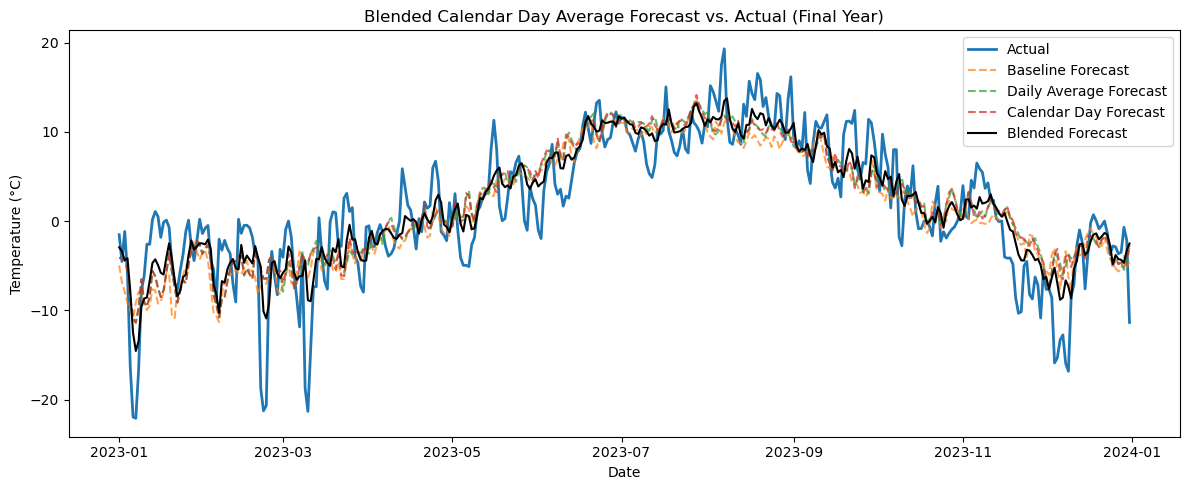

SMAPE for Blended Model on Final Year: 18.52%


In [17]:
# Create a column with the previous day's temperature 
df["Prev_Temp"] = df["min_temperature"].shift(1)

# Add the previous day's temperature to the test set
test["Prev_Temp"] = df.loc[test.index, "Prev_Temp"]

# Create a blended forecast by combining calendar-day average and previous day's temperature
# 70% weight to seasonal calendar-day average, 30% to previous day temperature

blended_forecast = 0.7 * calendar_day_forecast.values + 0.3 * test["Prev_Temp"].values

# Plot actual vs. forecast
plt.figure(figsize=(12, 5))
plt.plot(actual.index, actual, label='Actual', linewidth=2)
plt.plot(actual.index, baseline_forecast, label='Baseline Forecast', linestyle='--', alpha=0.7)
plt.plot(actual.index, day_avg_forecast, label='Daily Average Forecast', linestyle='--', alpha=0.7)
plt.plot(actual.index, calendar_day_forecast, label='Calendar Day Forecast', linestyle='--', alpha=0.7)
plt.plot(actual.index, blended_forecast, label='Blended Forecast', linestyle='-', color='black')
plt.title('Blended Calendar Day Average Forecast vs. Actual (Final Year)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

# SMAPE Calculation
smape_bcdm = np.mean(np.abs(test['min_temperature'] - blended_forecast) / (np.abs(test['min_temperature']) + np.abs(blended_forecast))/2) * 100
print(f"SMAPE for Blended Model on Final Year: {smape_bcdm:.2f}%")

Finally we see a drop in deviation by 2.3% to SMAPE = 18.52%. We also can see how adding a timely more near feature like the day's before temperature lead to much better capture of the test dataset's short term fluctutations. Nevertheless, there is still room to improve. 

In [2]:
import numpy as np
np.repeat(1/(30*48), 30*48)

array([0.00069444, 0.00069444, 0.00069444, ..., 0.00069444, 0.00069444,
       0.00069444], shape=(1440,))